# 2. Object recognition
 
Detect objects in images by predicting bounding boxes around them and evaluate the performance of object recognition models.

## Prepare environment

In [1]:
# Importing libraries
import expectexception
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import random
import torch
import torch.nn as nn
import PIL

from environment import prepare_environment
from typing import List
from operator import itemgetter
from torchvision import transforms
from torchvision.models import (vgg16, VGG16_Weights, mobilenet_v2,
                                mobilenet_v2, MobileNet_V2_Weights)
from torchvision.models.detection import (ssd300_vgg16, SSD300_VGG16_Weights, 
                                          FasterRCNN, fasterrcnn_resnet50_fpn)
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.rpn import AnchorGenerator
from torchvision.io import read_image
from torchvision.ops import nms, box_iou, MultiScaleRoIAlign
from torchvision.utils import draw_bounding_boxes

In [2]:
# Check if your GPU driver and CUDA is enabled and accessible by PyTorch
print(torch.__version__)
print('Cuda is available?', torch.cuda.is_available())

2.4.1+cu124
Cuda is available? True


In [3]:
# Global variables
SEED = 42

GPU_DEVICE = torch.cuda.current_device() if torch.cuda.is_available() else None

DATASET_CATS_AND_DOGS_TRAIN = "data-sources/cats_and_dogs/training_set/"
DATASET_CATS_AND_DOGS_TEST = "data-sources/cats_and_dogs/test_set/"

ARTIFACTS_FOLDER = "artifacts/"

In [4]:
# Global configuration
prepare_environment()

torch.set_printoptions(precision=10)
torch.set_default_dtype(torch.float32)
torch.set_printoptions(threshold=10) # Default number of elements to print

# Reproducibility
np.random.seed(SEED)
_ = torch.manual_seed(SEED)

### Util functions

In [5]:
def show_tensor_pil_image(image:[torch.Tensor, PIL.Image.Image],
                          title:str='Tensor Image',
                          figsize=(2, 2)) -> None:
    fig = plt.figure(figsize=figsize)
    plt.title(title)
    plt.axis('off')
    if type(image)==torch.Tensor:
        plt.imshow(image.permute(1, 2, 0))
        # if image.dtype == torch.float32
        #     plt.imshow(np.clip(image.permute(1, 2, 0), 0, 1))
        # else:
        #     plt.imshow(np.clip(image.permute(1, 2, 0), 0, 255))
    else:
        plt.imshow(image)
    plt.show()

## 2.1 Bounding boxes

### Bounding Box Prediction using PyTorch

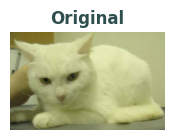

Total categories: 91


In [6]:
# Read image
image_file = 'data-sources/channels-example/cat.13.jpg'
image = read_image(image_file)
show_tensor_pil_image(image, title='Original')

# Step 1: Initialize model with the best available weights
weights = SSD300_VGG16_Weights.DEFAULT
categories = weights.meta["categories"]
print('Total categories:', len(categories))
model = ssd300_vgg16(weights=weights)
model.eval()

# Step 2: Initialize the inference transforms
preprocess = weights.transforms()

# Step 3: Apply inference preprocessing transforms
batch = preprocess(image).unsqueeze(0)

# Step 4: Use the model and print the predicted category
with torch.no_grad():
    predictions = model(batch)  # boxes, scores, labels

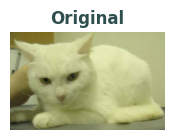

Num. of detected objects:  1

    Object Detected No.1:
    
    Boxes: 95
    First 2 boxes:
    tensor([[  5.3799452782,   7.4184446335, 495.9171752930, 311.9830932617],
        [  0.8996989727,  52.6315269470,  35.4277687073, 137.7490844727]])

    Scores: 95
    First 10 scores:
    tensor([0.9918015599, 0.0478853174, 0.0377737358, 0.0359373577, 0.0335009284,
        0.0318942368, 0.0297974776, 0.0275245029, 0.0273333713, 0.0268112831])

    Labels: 95
    First 10 labels:
    ['cat', 'book', 'book', 'cat', 'cat', 'book', 'bed', 'bed', 'book', 'book']
    

Finding the object with the greatest probability:

The first object (index=0) in Boxes, Scores and Labels contains the 
detected object with the greates probability:
cat - 99.1802% - [5.379945278167725, 7.418444633483887, 495.91717529296875, 311.98309326171875]

Index of higher score: 0



In [7]:
# Reviewing predictions
show_tensor_pil_image(image, title='Original')
print('Num. of detected objects: ', len(predictions))
for i, prediction in enumerate(predictions):
    boxes = prediction['boxes']
    scores = prediction['scores']
    labels = prediction['labels']
    labels_name = [categories[label] for label in labels]   
    print(f"""
    Object Detected No.1:
    
    Boxes: {len(boxes)}
    First 2 boxes:
    {boxes[:2]}

    Scores: {len(scores)}
    First 10 scores:
    {scores[:10]}

    Labels: {len(labels_name)}
    First 10 labels:
    {labels_name[:10]}
    """)

print(f"""
Finding the object with the greatest probability:

The first object (index=0) in Boxes, Scores and Labels contains the 
detected object with the greates probability:
{labels_name[0]} - {100 * scores[0]:.4f}% - {boxes[0].tolist()}

Index of higher score: {scores.argmax()}
""")

In [8]:
# Finding object with p>0.5
# NMS iteratively removes lower scoring boxes which have an IoU greater 
# than iou_threshold with another (higher scoring) box.
box_indices = nms(boxes=boxes, scores=scores, iou_threshold=0.4)
print('Total items:', len(box_indices))
print(box_indices)
print([categories[labels[index]] for index in box_indices])

Total items: 56
tensor([ 0,  1,  4,  ..., 92, 93, 94])
['cat', 'book', 'cat', 'book', 'bed', 'book', 'book', 'person', 'person', 'cat', 'person', 'teddy bear', 'book', 'cup', 'cup', 'book', 'book', 'dining table', 'person', 'book', 'person', 'person', 'tie', 'cat', 'cat', 'tie', 'cat', 'tie', 'tie', 'cat', 'person', 'keyboard', 'person', 'tie', 'person', 'dining table', 'keyboard', 'tie', 'keyboard', 'tv', 'keyboard', 'book', 'cat', 'person', 'remote', 'cup', 'cat', 'book', 'tie', 'person', 'tie', 'cat', 'tie', 'clock', 'book', 'person']


### Model 1: PreTrainedBoundingBoxWithSsd300Vgg16 (Pretrained Model)

In [9]:
# Pretrained ssd300_vgg16(pretrained = True)
class PreTrainedBoundingBoxWithSsd300Vgg16:
    """A custom class to load the ssd300_vgg16 pretrained model to predict
    boundering box, score, and label.
    Only one [box, score, label] are retorned."""
    def __init__(self):
        # Step 1: Initialize model with the best available weights
        self.weights = SSD300_VGG16_Weights.DEFAULT
        self.categories = self.weights.meta["categories"]
        self.model = ssd300_vgg16(weights=self.weights)
        self.model.eval()

        # Step 2: Initialize the inference transforms
        self.preprocess = self.weights.transforms()

    def _predict(self, image_file):
        # Read the image
        self.original_image = read_image(image_file)

        # Step 3: Apply inference preprocessing transforms
        self.images = self.preprocess(self.original_image).unsqueeze(0)

        # Step 4: Use the model and print the predicted category
        with torch.no_grad():
            predictions = self.model(self.images)
        self.predictions = predictions
            
    def predict_one(self, image_file):
        self._predict(image_file)
        
        # As we only process one image:
        prediction = predictions[0]
        prediction = {'box': prediction['boxes'][0],  # First box
                      'score': prediction['scores'][0],  # First score
                      'label': self.categories[prediction['labels'][0]],
                      'image': self.images.squeeze(0),}  # First label
        return prediction

    def predict_all(self, image_file):
        self._predict(image_file)
        predictions = self.predictions.copy()
        for prediction, image in zip(self.predictions, self.images):
            prediction['image'] = image
            prediction['labels'] = [self.categories[label] for label in prediction['labels']]
        return predictions

In [10]:
boundingbox = PreTrainedBoundingBoxWithSsd300Vgg16()
boundingbox.model

SSD(
  (backbone): SSDFeatureExtractorVGG(
    (features): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
      (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (6): ReLU(inplace=True)
      (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (8): ReLU(inplace=True)
      (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (11): ReLU(inplace=True)
      (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (13): ReLU(inplace=True)
      (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (15): ReLU(inplace=

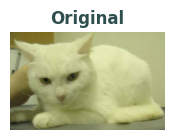

{'box': tensor([  5.3799452782,   7.4184446335, 495.9171752930, 311.9830932617]),
 'score': tensor(0.9918015599),
 'label': 'cat',
 'image': tensor([[[0.3490196168, 0.3529411852, 0.3568627536,  ..., 0.6823529601,
           0.6823529601, 0.6823529601],
          [0.3647058904, 0.3647058904, 0.3725490272,  ..., 0.6862745285,
           0.6862745285, 0.6862745285],
          [0.3803921640, 0.3843137324, 0.3882353008,  ..., 0.6901960969,
           0.6901960969, 0.6901960969],
          ...,
          [0.2784313858, 0.2823529541, 0.2862745225,  ..., 0.4117647111,
           0.4117647111, 0.4117647111],
          [0.2666666806, 0.2705882490, 0.2784313858,  ..., 0.3843137324,
           0.3843137324, 0.3843137324],
          [0.2588235438, 0.2627451122, 0.2705882490,  ..., 0.3607843220,
           0.3607843220, 0.3607843220]],
 
         [[0.2941176593, 0.2980392277, 0.3019607961,  ..., 0.7098039389,
           0.7098039389, 0.7098039389],
          [0.3098039329, 0.3098039329, 0.3176470697

In [11]:
# Read image
image_file = 'data-sources/channels-example/cat.13.jpg'
image = read_image(image_file)
show_tensor_pil_image(image, title='Original')

# Instantiate the model PreTrainedBoundingBoxWithSsd300Vgg16
boundingbox = PreTrainedBoundingBoxWithSsd300Vgg16()
boundingbox.predict_one(image_file)

### Converting pixels to tensors

#### Transforming with ToTensor()

- Tensor type: torch.float
- Scaled tensor range: [0.0, 1.0]

torch.Size([3, 410, 431])


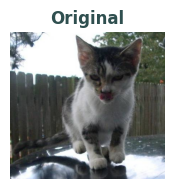

torch.Size([3, 224, 235])
tensor([0.9176470637, 0.8588235378, 0.9254902005,  ..., 0.9215686321,
        0.9333333373, 0.9450980425])


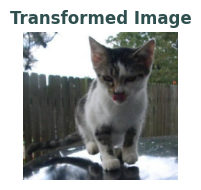

In [12]:
# Read image
image_file = 'data-sources/channels-example/cat.11.jpg'
image = read_image(image_file)
print(image.shape)
show_tensor_pil_image(image, title='Original')

# Load the dataset
image = PIL.Image.open(image_file)
transform = transforms.Compose([
                transforms.Resize(224),
                transforms.ToTensor(),
            ])
image_tensor = transform(image)
print(image_tensor.shape)
print(image_tensor.flatten())
show_tensor_pil_image(image_tensor, title='Transformed Image')

#### Tranforming with PILToTensor()

- Tensor type: torch.uint8 (8-bit integer)
- Unscaled tensor range: [0, 255]

torch.Size([3, 410, 431])


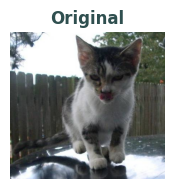

torch.Size([3, 224, 235])
tensor([234, 219, 236,  ..., 235, 238, 241], dtype=torch.uint8)


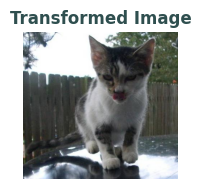

In [13]:
# Read image
image_file = 'data-sources/channels-example/cat.11.jpg'
image = read_image(image_file)
print(image.shape)
show_tensor_pil_image(image, title='Original')

# Load the dataset
image = PIL.Image.open(image_file)
transform = transforms.Compose([
                transforms.Resize(224),
                transforms.PILToTensor()
            ])
image_tensor = transform(image)
print(image_tensor.shape)
print(image_tensor.flatten())
show_tensor_pil_image(image, title='Transformed Image')

### Drawing the bounding box

- Import `draw_bounding_boxes`
- Collect coordinates into a tensor
- Unsqueeze to two dimensions
- Transform to image and plot

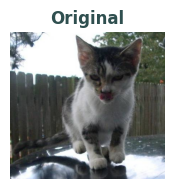

{'box': tensor([  5.3799452782,   7.4184446335, 495.9171752930, 311.9830932617]),
 'score': tensor(0.9918015599),
 'label': 'cat',
 'image': tensor([[[0.9215686321, 0.9058823586, 0.8352941275,  ..., 0.2392156869,
           0.2274509817, 0.2078431398],
          [0.9764705896, 0.9215686321, 0.8117647171,  ..., 0.2431372553,
           0.2392156869, 0.2235294133],
          [0.9490196109, 0.8745098114, 0.7607843280,  ..., 0.2470588237,
           0.2470588237, 0.2313725501],
          ...,
          [0.3490196168, 0.4901960790, 0.6666666865,  ..., 0.7803921700,
           0.7803921700, 0.7803921700],
          [0.3490196168, 0.4509803951, 0.5294117928,  ..., 0.7764706016,
           0.7921568751, 0.7882353067],
          [0.3490196168, 0.4509803951, 0.5294117928,  ..., 0.7764706016,
           0.7921568751, 0.7882353067]],
 
         [[0.9450980425, 0.9294117689, 0.8705882430,  ..., 0.2980392277,
           0.2862745225, 0.2666666806],
          [1.0000000000, 0.9450980425, 0.8470588326

In [14]:
# Read image
image_file = 'data-sources/channels-example/cat.11.jpg'
image = read_image(image_file)
show_tensor_pil_image(image, title='Original')

# Instantiate the model PreTrainedBoundingBoxWithSsd300Vgg16
boundingbox = PreTrainedBoundingBoxWithSsd300Vgg16()
bounding = boundingbox.predict_one(image_file)
bounding

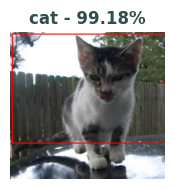

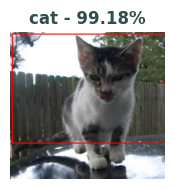

In [15]:
bbox = bounding['box'].unsqueeze(0)
tensor_image = bounding['image']
bbox_image = draw_bounding_boxes(tensor_image, bbox, width=3, colors="red")

title_image = f"{bounding['label']} - {100 * bounding['score']:.2f}%"

# plotting the tensor image inmediately
show_tensor_pil_image(bbox_image, title=title_image)

# Or transform it to pil and plot
transform = transforms.Compose([
                transforms.ToPILImage()
            ])
pil_image = transform(bbox_image)
show_tensor_pil_image(pil_image, title=title_image)

### Ex.1 - Image tensors

A coffee company has an object detection project where they need to annotate objects of interest, in this case, espresso shots. You have created a list with the bounding box coordinates for an espresso shot image. Now, you need to convert the image and the coordinates into tensors.

`torch` and `torchvision` have been imported. `torchvision.transforms` is imported as `transforms`. The image has been loaded as image using `Image.open()` from `PIL` library. The bounding box coordinates are stored in the variable `bbox`.

![cup-of-coffee](data-sources/channels-example/Espresso.jpeg)

**Instructions**

1. Convert the `bbox` into tensors using `torch.tensor()`.
2. Reshape `bbox_tensor` by adding a batch dimension using `unsqueeze(0)`.
3. Create a transform to resize image to (`224`) and transform to an unscaled image tensor.
4. Apply transform to `image`.

RGB (233, 218)


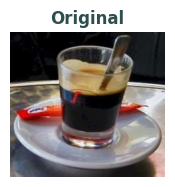

torch.Size([3, 224, 239])


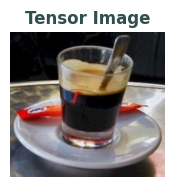

In [16]:
# Bounding box coordinates for the image
bbox = [10, 10, 200, 200]

# Read image
image_file = "data-sources/channels-example/Espresso.jpeg"
image = PIL.Image.open(image_file)
print(image.mode, image.size)
show_tensor_pil_image(image, title='Original')

# Convert bbox into tensors
bbox_tensor = torch.tensor(bbox)

# Add a new batch dimension
bbox_tensor = bbox_tensor.unsqueeze(0)

# Resize the image and transform to tensor
transform = transforms.Compose([
  transforms.Resize(224),
  transforms.ToTensor()
])

# Apply transform to image
image_tensor = transform(image)
print(image_tensor.shape)
show_tensor_pil_image(image_tensor)

**Great! Usually, we use `transforms.ToTensor()` float transformation for images to scale them in the range `[0,1]`. However, the bounding box requires an unscaled image type with the range `[0, 255]`, so we use `transforms.PILToTensor()`.**

#### More information of image using `PIL`

In [17]:
# returns a dict containing various information about the image.
image.info

{'jfif': 257,
 'jfif_version': (1, 1),
 'jfif_unit': 0,
 'jfif_density': (1, 1),
 'progressive': 1,
 'progression': 1}

In [18]:
# returns a tuple containing all different channel present in the data.
image.getbands()

('R', 'G', 'B')

#### Reading transparent image with PIL

In [19]:
# Reading a ransparent image
image = PIL.Image.open("data-sources/channels-example/dog-transparent.png")
print(image.info)
print(image.getbands())
print(image.mode, image.size)

{}
('R', 'G', 'B', 'A')
RGBA (1110, 772)


#### Using our `PreTrainedBoundingBoxWithSsd300Vgg16` class to solve it

In [20]:
# Read image
image_file = "data-sources/channels-example/Espresso.jpeg"
image = read_image(image_file)

# Instantiate the model PreTrainedBoundingBoxWithSsd300Vgg16
boundingbox = PreTrainedBoundingBoxWithSsd300Vgg16()
bounding = boundingbox.predict_one(image_file)
bounding

{'box': tensor([  5.3799452782,   7.4184446335, 495.9171752930, 311.9830932617]),
 'score': tensor(0.9918015599),
 'label': 'cat',
 'image': tensor([[[0.0000000000, 0.0000000000, 0.0000000000,  ..., 0.0980392173,
           0.0941176489, 0.0901960805],
          [0.0000000000, 0.0000000000, 0.0000000000,  ..., 0.1019607857,
           0.0980392173, 0.0901960805],
          [0.0000000000, 0.0000000000, 0.0000000000,  ..., 0.1058823541,
           0.1058823541, 0.0901960805],
          ...,
          [0.5098039508, 0.5176470876, 0.5176470876,  ..., 0.9137254953,
           0.9137254953, 0.9058823586],
          [0.5294117928, 0.5294117928, 0.5294117928,  ..., 0.8862745166,
           0.8862745166, 0.9019607902],
          [0.5294117928, 0.5372549295, 0.5294117928,  ..., 0.8862745166,
           0.8862745166, 0.9019607902]],
 
         [[0.0039215689, 0.0039215689, 0.0039215689,  ..., 0.1176470593,
           0.1137254909, 0.1098039225],
          [0.0039215689, 0.0039215689, 0.0039215689

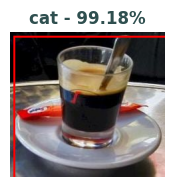

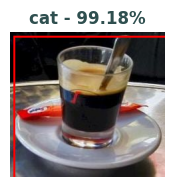

In [21]:
bbox = bounding['box'].unsqueeze(0)
tensor_image = bounding['image']
bbox_image = draw_bounding_boxes(tensor_image, bbox, width=3, colors="red")

image_title = f"{bounding['label']} - {100 * bounding['score']:.2f}%"

# You can plot the tensor result bbox_image
show_tensor_pil_image(bbox_image, title=image_title)

# Or you can transform the image to pil and then print it
transform = transforms.Compose([ transforms.ToPILImage() ])
pil_image = transform(bbox_image)
show_tensor_pil_image(pil_image, title=image_title)

### Ex.2 - Drawing a bounding box

Having prepared the image and bounding box tensors, you can now draw the box on top of the image and visually inspect its accuracy.

torch, torchvision,torchvision.transforms have been imported. Image has been already transformed to tensors as image_tensor. The coordinates have been assigned to the variables: x_min, y_min, x_max, y_max.

**Instructions**

1. Import `draw_bounding_boxes` from `torchvision.utils`.
2. Define the bounding box `bbox` as list consisting of `x_min`, `y_min`, `x_max`, and `y_max`.
3. Pass `image_tensor` and `bbox_tensor` to `draw_bounding_boxes` to draw the box on top of the image and assign the output to `img_bbox`.
4. Convert the `img_bbox` tensor to image.

[70, 17, 190, 180]


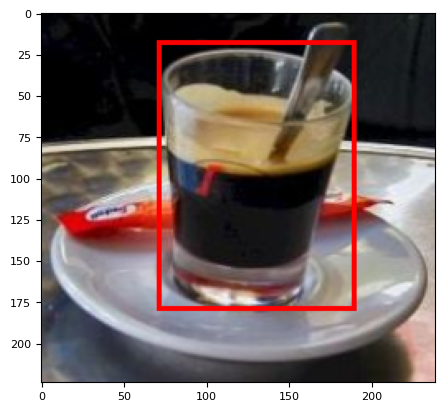

In [22]:
# Read image
image_file = "data-sources/channels-example/Espresso.jpeg"
image = PIL.Image.open(image_file)

# Resize the image and transform to tensor
transform = transforms.Compose([
  transforms.Resize(224),
  transforms.ToTensor()
])

# Apply transform to image
image_tensor = transform(image)

# Bounding coordinates for the image
x_min, y_min, x_max, y_max = (70, 17, 190, 180)

# Define the bounding box coordinates
bbox = [x_min, y_min, x_max, y_max]
bbox_tensor = torch.tensor(bbox).unsqueeze(0)
print(bbox)

# Implement draw_bounding_boxes
img_bbox = draw_bounding_boxes(image_tensor, bbox_tensor, width=3, colors="red")

# Tranform tensors to image
transform = transforms.Compose([
    transforms.ToPILImage()
])
plt.imshow(transform(img_bbox))
plt.show()

## 2.2 Evaluating object recognition models

### IoU in PyTorch

IoU: tensor([[0.1428571492]])


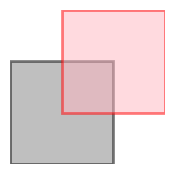

In [23]:
# Two sets of boxes
bbox1 = [50, 50, 150, 150]
bbox2 = [100, 100, 200, 200]

# Convert vectors to 2-D tensors
bbox1 = torch.tensor(bbox1).unsqueeze(0)
bbox2 = torch.tensor(bbox2).unsqueeze(0)

# Calculate IoU
iou = box_iou(bbox1, bbox2)
print("IoU:", iou)

# Plotting the squares
_, ax = plt.subplots(figsize=(2, 2))
square1 = patches.Rectangle((50, 50), width=150 - 50, height= 150 - 50,
                            linewidth=2, edgecolor='black', facecolor='gray', alpha=0.5)
square2 = patches.Rectangle((100, 100), width=200 - 100, height= 200 - 100,
                            linewidth=2, edgecolor='red', facecolor='lightpink', alpha=0.5)
ax.add_patch(square1)
ax.add_patch(square2)
ax.set_xlim(50, 200)
ax.set_ylim(50, 200)
plt.axis('off')
plt.show()

### Predicting bounding boxes

In [24]:
# Read image
image_file = "data-sources/channels-example/Campo.jpg"
image = read_image(image_file)

# Instantiate the model PreTrainedBoundingBoxWithSsd300Vgg16
boundingbox = PreTrainedBoundingBoxWithSsd300Vgg16()
boundings = boundingbox.predict_all(image_file)
boundings

[{'boxes': tensor([[301.5047607422,  64.1415557861, 590.4226074219, 326.0428161621],
          [159.3880462646, 193.6788787842, 206.8462371826, 322.1420898438],
          [415.2599487305, 212.9309844971, 566.4857788086, 327.3364562988],
          ...,
          [ 20.6324977875, 204.9296417236,  30.4906768799, 211.2126312256],
          [ 48.9649047852, 159.3027496338,  59.3474197388, 164.8724517822],
          [221.1093139648, 286.0542297363, 228.8500061035, 296.0313415527]]),
  'scores': tensor([0.9987993240, 0.9985210299, 0.0830424652,  ..., 0.0245801117,
          0.0245624054, 0.0245435517]),
  'labels': ['horse',
   'person',
   'horse',
   'person',
   'horse',
   'horse',
   'person',
   'backpack',
   'person',
   'horse',
   'kite',
   'horse',
   'kite',
   'horse',
   'kite',
   'kite',
   'horse',
   'horse',
   'backpack',
   'kite',
   'horse',
   'kite',
   'kite',
   'kite',
   'person',
   'horse',
   'kite',
   'kite',
   'person',
   'person',
   'person',
   'kite',

In [25]:
for bounding in boundings:
    person_indices = [i for i, item in enumerate(bounding['labels']) if item == 'person']
    print('Total identified figures:', len(bounding['labels']))
    print('Identified person figure in image:', len(person_indices))
    print(person_indices)

Total identified figures: 200
Identified person figure in image: 38
[1, 3, 6, 8, 24, 28, 29, 30, 33, 37, 40, 48, 55, 62, 65, 70, 82, 86, 89, 113, 114, 116, 125, 126, 132, 133, 138, 142, 143, 145, 157, 164, 166, 182, 185, 188, 191, 199]


### Non-max suppression (NMS) - All objects

#### First try - plotting all as it comes

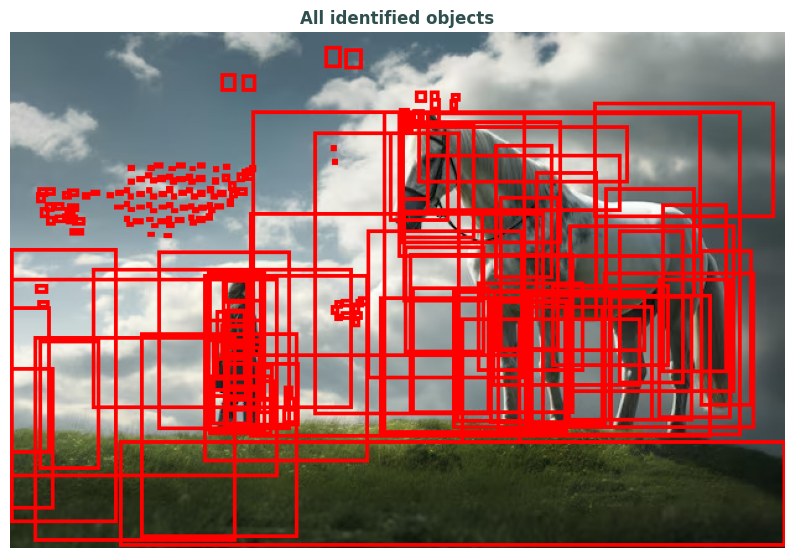

In [26]:
# Printing all boxes
tensor_image = bounding['image'] # The last one is the only item

bbox_image = draw_bounding_boxes(tensor_image, bounding['boxes'], width=3, colors="red")
show_tensor_pil_image(bbox_image, title='All identified objects', figsize=(10, 10))

#### Second try - plotting score and label as well

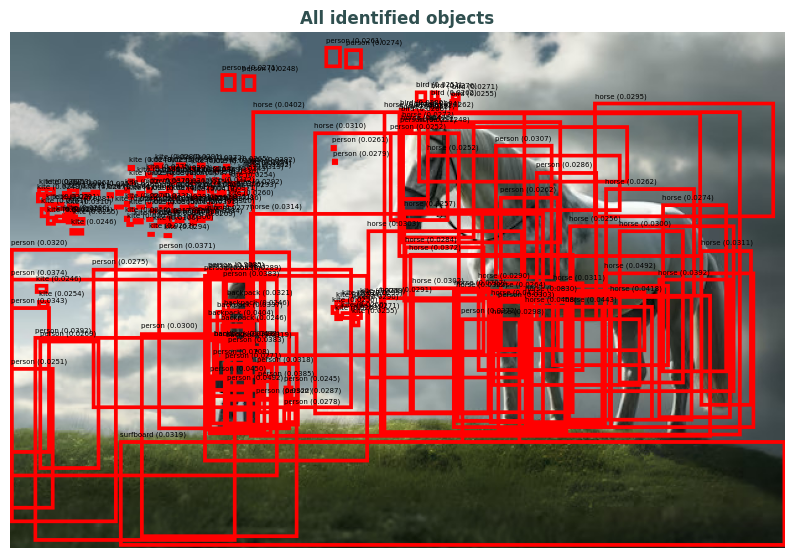

In [27]:
# Improving the previous code
tensor_image = bounding['image'] # The last one is the only item

fig = plt.figure(figsize=(10, 10))
plt.title('All identified objects')
bbox_image = draw_bounding_boxes(tensor_image, bounding['boxes'], width=3, colors="red")
plt.imshow(bbox_image.permute(1, 2, 0))
for box, label, score in zip(bounding['boxes'], bounding['labels'], bounding['scores']):
    plt.text(x=box[0].item(), y=box[1].item()-5,
             s=f"{label} ({score.item():.4f})", fontsize=5)
plt.axis('off')
plt.show()

#### Third try - plotting after removing overlapping 0.1

Original total of identified figures: 200
Total items after nms: 128
tensor([  0,   1,   9,  ..., 197, 198, 199])
Original identified objects: {'backpack', 'bird', 'surfboard', 'person', 'kite', 'horse', 'handbag'}
Identified objects after nms: {'horse', 'kite', 'person', 'bird'}


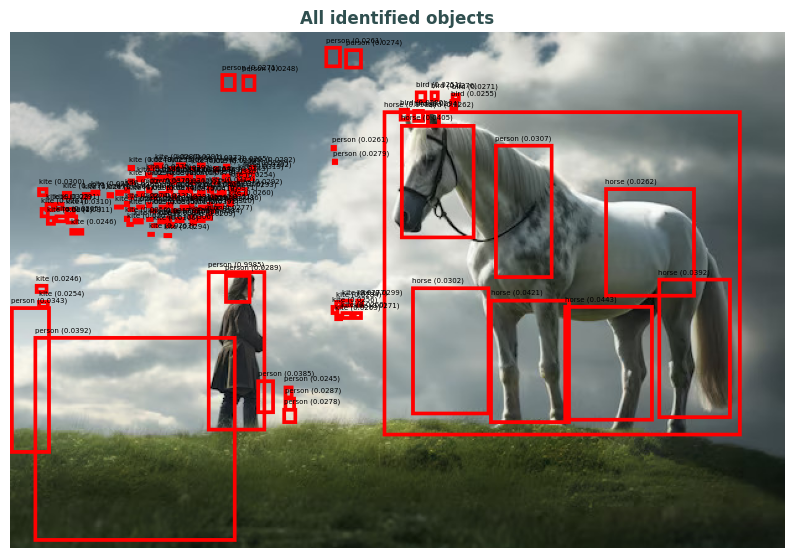

In [28]:
# Improving previous code
box_indices = nms(boxes=bounding['boxes'], 
                  scores=bounding['scores'], iou_threshold=0.1)
print('Original total of identified figures:', len(bounding['labels']))
print('Total items after nms:', len(box_indices))
print(box_indices)
print('Original identified objects:', set(bounding['labels']))
print('Identified objects after nms:', 
      set(itemgetter(*box_indices)(bounding['labels'])))

tensor_image = bounding['image'] # The last one is the only item

fig = plt.figure(figsize=(10, 10))
plt.title('All identified objects')
bbox_image = draw_bounding_boxes(tensor_image, bounding['boxes'][box_indices],
                                 width=3, colors="red")
plt.imshow(bbox_image.permute(1, 2, 0))
for box, label, score in zip(bounding['boxes'][box_indices],
                             itemgetter(*box_indices)(bounding['labels']),
                             bounding['scores'][box_indices]):
    plt.text(x=box[0].item(), y=box[1].item()-5,
             s=f"{label} ({score.item():.4f})", fontsize=5)
plt.axis('off')
plt.show()

#### Fourth try - plotting first instance of each object (not a good idea)

Identified figures: ('backpack', 'bird', 'surfboard', 'person', 'kite', 'horse', 'handbag')


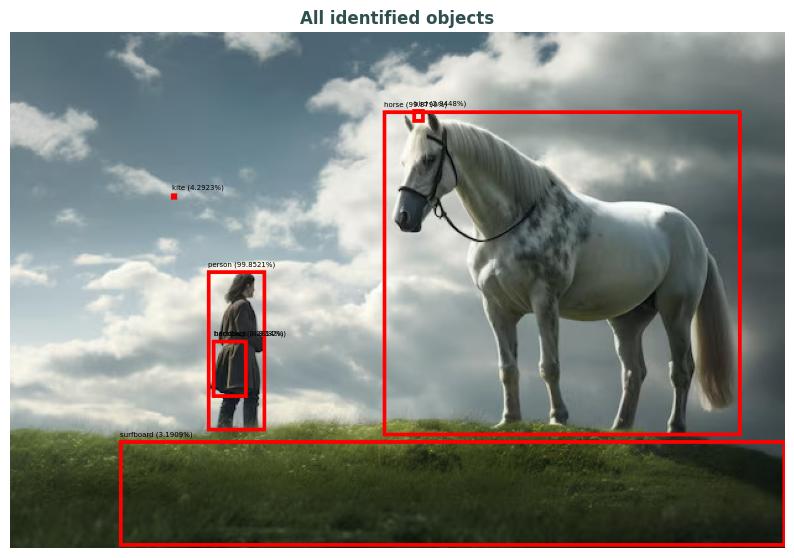

In [29]:
# Improving previous code
object_index = [bounding['labels'].index(object)
                for object in set(bounding['labels'])]
print('Identified figures:', itemgetter(*object_index)(bounding['labels']))

tensor_image = bounding['image'] # The last one is the only item

fig = plt.figure(figsize=(10, 10))
plt.title('All identified objects')
bbox_image = draw_bounding_boxes(tensor_image, bounding['boxes'][object_index],
                                 width=3, colors="red")
plt.imshow(bbox_image.permute(1, 2, 0))
for box, label, score in zip(bounding['boxes'][object_index],
                             itemgetter(*object_index)(bounding['labels']),
                             bounding['scores'][object_index]):
    plt.text(x=box[0].item(), y=box[1].item()-5,
             s=f"{label} ({100 * score.item():.4f}%)", fontsize=5)
plt.axis('off')
plt.show()

#### Fifth try - plotting only score>0.3

Printing first 5 labels: ['horse', 'person', 'horse', 'person', 'horse']
Printing first 5 scores: tensor([0.9987993240, 0.9985210299, 0.0830424652, 0.0707628652, 0.0707004517])
Total objects with score>0.3: 2


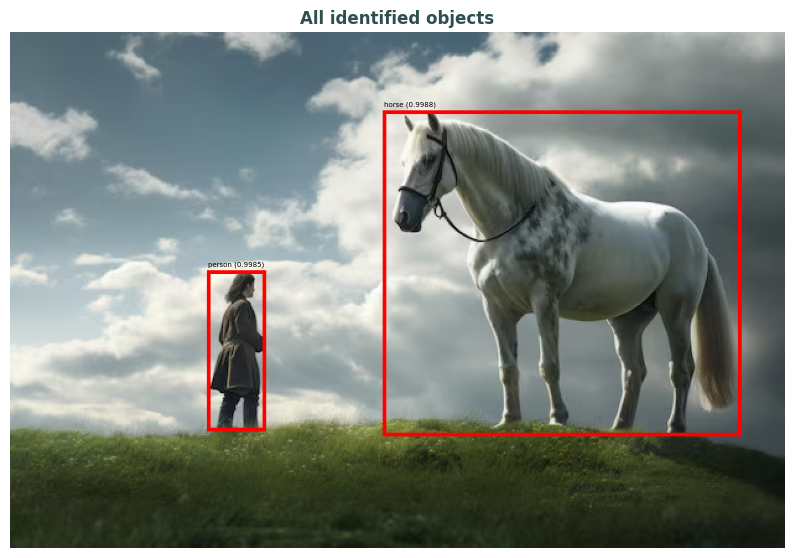

In [30]:
# Improving previous code
print('Printing first 5 labels:', bounding['labels'][:5])
print('Printing first 5 scores:', bounding['scores'][:5])

# Getting index of object with score>0.3
box_indices = (bounding['scores'] > 0.3).nonzero(as_tuple=False).flatten()
print('Total objects with score>0.3:', len(box_indices))

tensor_image = bounding['image'] # The last one is the only item

fig = plt.figure(figsize=(10, 10))
plt.title('All identified objects')
bbox_image = draw_bounding_boxes(tensor_image, bounding['boxes'][box_indices],
                                 width=3, colors="red")
plt.imshow(bbox_image.permute(1, 2, 0))
for box, label, score in zip(bounding['boxes'][box_indices],
                             itemgetter(*box_indices)(bounding['labels']),
                             bounding['scores'][box_indices]):
    plt.text(x=box[0].item(), y=box[1].item()-5,
             s=f"{label} ({score.item():.4f})", fontsize=5)
plt.axis('off')
plt.show()

### Non-max suppression (NMS) - Person object only

#### First try - plotting all detected person figures

Identified person figure in image: 38
Person figure with the greatest p: 0.9987993240356445


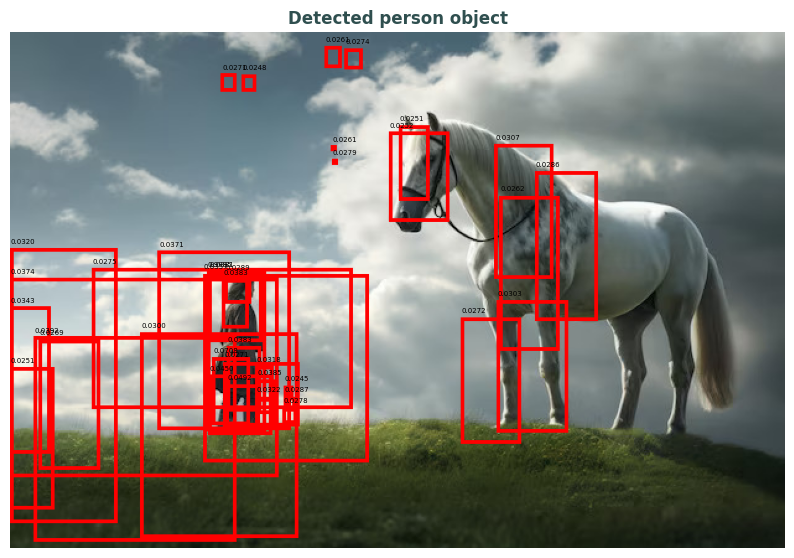

In [31]:
# Printing only person identified
person_indices = [i for i, item in enumerate(bounding['labels']) if item == 'person']

print('Identified person figure in image:', len(person_indices))
print('Person figure with the greatest p:', bounding['scores'][0].item())

tensor_image = bounding['image'] # The last one is the only item

fig = plt.figure(figsize=(10, 10))
plt.title('Detected person object')
bbox_image = draw_bounding_boxes(tensor_image, bounding['boxes'][person_indices],
                                 width=3, colors="red")
plt.imshow(bbox_image.permute(1, 2, 0))
for box, score in zip(bounding['boxes'][person_indices],
                             bounding['scores'][person_indices]):
    plt.text(x=box[0].item(), y=box[1].item()-5,
             s=f"{score.item():.4f}", fontsize=5)
plt.axis('off')
plt.show()

#### Second try - plotting only score>0.3

Printing first 5 scores for person figure: tensor([0.9985210299, 0.0707628652, 0.0492133833, 0.0449913964, 0.0391666368])
Total objects with score>0.3: 1


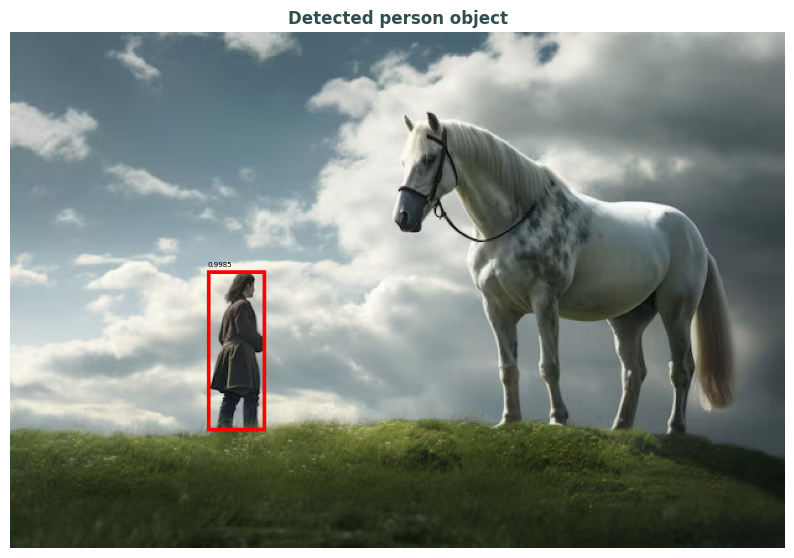

In [32]:
# Printing only person identified with score>0.3
person_indices = [i for i, item in enumerate(bounding['labels']) if item == 'person']
person_scores = bounding['scores'][person_indices]
person_boxes = bounding['boxes'][person_indices]
box_indices = (person_scores > 0.3).nonzero(as_tuple=False).flatten()

print('Printing first 5 scores for person figure:', 
      person_scores[:5])
print('Total objects with score>0.3:', len(box_indices))
tensor_image = bounding['image'] # The last one is the only item

fig = plt.figure(figsize=(10, 10))
plt.title('Detected person object')
bbox_image = draw_bounding_boxes(tensor_image, person_boxes[box_indices],
                                 width=3, colors="red")
plt.imshow(bbox_image.permute(1, 2, 0))
for box, score in zip(person_boxes[box_indices],
                      person_scores[box_indices]):
    plt.text(x=box[0].item(), y=box[1].item()-5,
             s=f"{score.item():.4f}", fontsize=5)
plt.axis('off')
plt.show()

### Ex.3 - Calculate IoU

You have been asked to calculate the Intersection over Union (IoU) metric between each of the three predicted bounding boxes (`box_a`, `box_b`, `box_c`) and the ground truth box `bbox`.

`box_iou` has been imported from torchvision.ops. `box_a`, `box_b`, `box_c`, `bbox` has been already converted to `torch.int` type tensors with an additional batch dimension.

**Instructions**
Which predicted box is the closest to the ground truth?

Possible answers
- [ ] box_a
- [ ] box_b
- [X] box_c

In [33]:
bbox = torch.tensor([[30, 20, 60, 50]])

box_a = torch.tensor([[10, 10, 50, 50]])
box_b = torch.tensor([[30, 30, 70, 70]])
box_c = torch.tensor([[28, 15, 62, 55]])

print(f"""
IoU with box_a: {box_iou(bbox, box_a)}
IoU with box_b: {box_iou(bbox, box_b)}
IoU with box_c: {box_iou(bbox, box_c)}
""")


IoU with box_a: tensor([[0.3157894611]])
IoU with box_b: tensor([[0.3157894611]])
IoU with box_c: tensor([[0.6617646813]])



### Ex.4 - Bounding boxes prediction

You have trained an object recognition model. Now, you want to use to generate bounding boxes and classifications for a test image.

The model is available as `model` and it's already in the evaluation mode. The `test_image` is also available, and `torch` and `torch.nn` as `nn` have been imported.

**Instructions**

1. Get the model's output for the `test_image` and assign it to output.
2. Extract the predicted bounding boxes from the output and assign them to `boxes`.
3. Extract the predicted scores from the output and assign them to `scores`.

In [34]:
# Preparing fake environment
from figure import test_image  # fake loaded image

def model_fake(image):  # fake trained model
    # Simulate the behavior of a model prediction
    num_predictions = 5
    random_boxes = torch.rand(num_predictions, 4)
    random_scores = torch.FloatTensor([random.uniform(0.7, 1) 
                                       for _ in range(num_predictions)])
    random_labels = torch.LongTensor([random.randint(1, 3) 
                                      for _ in range(num_predictions)])
    prediction_output = [{
        'boxes': random_boxes,
        'scores': random_scores,
        'labels': random_labels
    }]    
    return prediction_output

In [35]:
# Get model's prediction
with torch.no_grad():
    output = model_fake(test_image)

# Extract boxes from the output
boxes = output[0]['boxes']

# Extract scores from the output
scores = output[0]['scores']

print(f"""
Boxes: 
{boxes}

Scores:
{scores}
""")


Boxes: 
tensor([[0.3562545180, 0.7407820225, 0.1774023175, 0.1338659525],
        [0.7884646654, 0.0078542233, 0.4510302544, 0.2708910704],
        [0.0880659223, 0.7931503654, 0.7687160969, 0.4191947579],
        [0.8960330486, 0.0551958084, 0.7200065255, 0.2054222226],
        [0.7219445705, 0.2595324516, 0.1772881746, 0.5261725783]])

Scores:
tensor([0.9107997417, 0.7293967605, 0.8891928792, 0.9025611281, 0.8664234877])



### Ex.5 - Calculate NMS

Having extracted the predicted bounding boxes and scores from your object recognition model, your next task is to ensure that only the most accurate and non-overlapping predicted bounding boxes are retained by using the non-max suppression technique.

`boxes` and `scores` you created in the previous exercise are available in your workspace and `torch` and `torchvision` have been imported.

**Instructions**

1. Import `nms` from `torchvision.ops`.
2. Set the `IoU` threshold to be equal `0.5`.
3. Apply non-max suppression passing `boxes`, `confidence_scores`, and `iou_threshold` to the relevant function.
4. Use the output indices to filter predicted boxes.

In [36]:
# Preparing the fake environment
boxes = torch.tensor([[ 55.,  30., 145., 120.],
                      [ 60.,  40., 120., 100.],
                      [ 70.,  50., 140., 120.],
                      [ 40.,  50., 140., 150.]])
scores = torch.tensor([0.8500, 0.8900, 0.9200, 0.9300])

# Set the IoU threshold
iou_threshold = 0.5

# Apply non-max suppression
box_indices = nms(boxes=boxes, scores=scores, iou_threshold=iou_threshold)

# Filter boxes
filtered_boxes = boxes[box_indices]

print("Original boxes:", len(boxes))
print("Filtered Boxes:", len(filtered_boxes))

Original boxes: 4
Filtered Boxes: 3


## 2.3 Object detection using R-CNN

### R-CNN: backbone with PyTorch

In [37]:
vgg = vgg16(weights=VGG16_Weights.DEFAULT)
vgg

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [38]:
# only convolutional layers
vgg.features

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (17): Conv2d(256, 512, kernel_si

In [39]:
# all layers from block
# list(vgg.children())
list(vgg.features.children())

[Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),
 ReLU(inplace=True),
 Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),
 ReLU(inplace=True),
 MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False),
 Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),
 ReLU(inplace=True),
 Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),
 ReLU(inplace=True),
 MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False),
 Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),
 ReLU(inplace=True),
 Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),
 ReLU(inplace=True),
 Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),
 ReLU(inplace=True),
 MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False),
 Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),
 ReLU(inplace=True),
 Conv2d(512, 512, kernel_size=(3, 3), stride=(1

In [40]:
# nn.Sequential(*list()) >> all sub-layersare placed into a sequential 
# block as a list, * unpacks the elements from the list
vgg_backbone = nn.Sequential(*list(vgg.features.children()))
vgg_backbone

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (17): Conv2d(256, 512, kernel_si

In [41]:
vgg.avgpool

AdaptiveAvgPool2d(output_size=(7, 7))

### R-CNN: classifier layer

In [42]:
# Extract backbone's output size
# That is the input of the classifier layer
input_dimension = nn.Sequential(*list(
                      vgg.classifier.children())
                  )[0].in_features
input_dimension

25088

In [43]:
# Create a new classifier
num_classes = 7
classifier = nn.Sequential(
    nn.Linear(input_dimension, 512),
    nn.ReLU(),
    nn.Linear(512, num_classes),
)
classifier

Sequential(
  (0): Linear(in_features=25088, out_features=512, bias=True)
  (1): ReLU()
  (2): Linear(in_features=512, out_features=7, bias=True)
)

### R-CNN: box regressor layer

- Sits on top of the backbone
- 4 outputs for the 4 box coordinates

In [44]:
box_regressor = nn.Sequential(
    nn.Linear(input_dimension, 32),
    nn.ReLU(),
    nn.Linear(32, 4),
)
box_regressor

Sequential(
  (0): Linear(in_features=25088, out_features=32, bias=True)
  (1): ReLU()
  (2): Linear(in_features=32, out_features=4, bias=True)
)

### Putting it all together: object detection model

#### Model 2: ObjectDetectionVgg16

In [45]:
class ObjectDetectionWithPreTrainedModelVgg16(nn.Module):
    def __init__(self):
        super().__init__()
        weights = VGG16_Weights.DEFAULT
        vgg = vgg16(weights=weights)
        num_classes = 2
        input_features = nn.Sequential(*list(vgg.classifier.children()))[0].in_features
        
        self.weights = weights
        self.image_preprocess = self.weights.transforms()
        self.backbone = nn.Sequential(*list(vgg.features.children()))
        self.backbone.add_module('flatten', nn.Flatten())
        self.classifier = nn.Sequential(nn.Linear(input_features, 512),
                                        nn.ReLU(),
                                        nn.Linear(512, num_classes))
        self.classifier.add_module('softmax', nn.Softmax(dim=-1))
        self.box_regressor = nn.Sequential(nn.Linear(input_features, 32),
                                           nn.ReLU(),
                                           nn.Linear(32, 4))
    def forward(self, x):
        features = self.backbone(x)
        bboxes = self.box_regressor(features)
        classes = self.classifier(features)
        return bboxes, classes

#### Testing Vgg16 Model

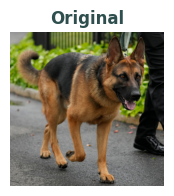

« German shepherd »: 97.9887%


In [46]:
# Read image
image_file = 'data-sources/channels-example/dog-rgb.jpg'
image = read_image(image_file)
show_tensor_pil_image(image, title='Original')

# Step 1: Initialize model with the best available weights
weights = VGG16_Weights.DEFAULT
categories = weights.meta["categories"]
model = vgg16(weights=weights)
model.eval()

# Step 2: Initialize the inference transforms
preprocess = weights.transforms()

# Step 3: Apply inference preprocessing transforms
batch = preprocess(image).unsqueeze(0)

# Step 4: Use the model and print the predicted category
with torch.no_grad():
    output = model(batch).squeeze(0).softmax(0)
class_id = output.argmax().item()
score = output[class_id].item()
category_name = categories[class_id]
print(f'« {category_name} »: {100 * score:.4f}%')

### Running object recognition

1. Load and transform the image
2. `unsqueeze()` the image to add the batch dimension
3. Pass the image tensor to the model
4. Run Non-Max Suppression (`nms()`) over model's output
5. `draw_bounding_boxes()` on top of the image

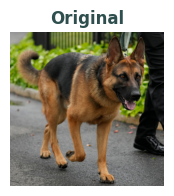

Output boxes: tensor([[ 0.3124042153,  0.7052809000, -0.3684681058,  0.7547085285]]), scores: tensor([0.5955098867]), classes: tensor([0])


ValueError: Boxes need to be in (xmin, ymin, xmax, ymax) format. Use torchvision.ops.box_convert to convert them

In [47]:
# Step 0: Initialize model
custom_vgg16 = ObjectDetectionWithPreTrainedModelVgg16()
preprocess = custom_vgg16.image_preprocess

# Step 1: Load the image
image_file = 'data-sources/channels-example/dog-rgb.jpg'
image = read_image(image_file)
show_tensor_pil_image(image, title='Original')

# Step 2: Transform and unsqueeze() the image to add the batch dimension
batch_image = preprocess(image).unsqueeze(0)

# Step 3: Pass the image tensor to the model
custom_vgg16.eval()
with torch.no_grad():
    output_boxes, output_classes = custom_vgg16(batch_image)

pred_scores, pred_classes = output_classes.max(dim=1)
print(f'Output boxes: {output_boxes}, scores: {pred_scores}, classes: {pred_classes}')

# Step 4: Run Non-Max Suppression ( nms() ) over model's output
iou_threshold = 0.5
box_indices = nms(boxes=output_boxes, scores=pred_scores, iou_threshold=iou_threshold)

# Step 5: draw_bounding_boxes() on top of the image
tensor_image = batch_image.squeeze(0)
pred_boxes = output_boxes[box_indices]
bbox_image = draw_bounding_boxes(tensor_image, pred_boxes, width=3, colors="red")

### Ex.6 - Pre-trained model backbone

It's time to build an R-CNN architecture! You will use the `vgg16` pre-trained model's backbone for feature extraction. You also remember to store the output shape of the backbone which will serve as the input shape for the subsequent blocks: the classifier and the box regressor.

`torch`, `torchvision`, `torch.nn` as `nn` have been imported. The model has been imported as `vgg16` with the weights stored in `VGG16_Weights`.

**Instructions**

1. Load the pre-trained VGG16 weights.
2. Extract `in_features` from the `classifier`'s first layer using `.children()` as a sequential block and store it as `input_dim`.
3. Create a backbone as a sequential block using `features` and `.children()`.
4. Print the backbone model.

**The pre-trained backbone is essential for extracting features from the input image.**

In [ ]:
# Load pretrained weights
vgg_model = vgg16(weights=VGG16_Weights.DEFAULT)

# Extract the input dimension
input_dim = nn.Sequential(*list(vgg_model.classifier.children()))[0].in_features

# Create a backbone with convolutional layers
backbone = nn.Sequential(*list(vgg_model.features.children()))

# Print the backbone model
print(backbone)

### Ex.7 - Classifier block

Your next task is to create a classifier block that will replace the original VGG16 classifier. You decide to use a block with two fully connected layers with a ReLU activation in between.

The `vgg_model` and `input_dim` you defined in the last exercise are available in your workspace, and `torch` and `torchvision.models` have been imported.

**Instructions**

1. Create a variable `num_classes` with the number of classes assuming you're dealing with detecting cats and dogs only.
2. Create a sequential block using `nn.Sequential`.
3. Create a linear layer with `in_features` set to `input_dim`.
4. Add the output features to the classifier's last layer.

In [ ]:
# Create a variable with the number of classes
num_classes = 2
    
# Create a sequential block
classifier = nn.Sequential(
	# Create a linear layer with input features
	nn.Linear(input_dim, 512),
	nn.ReLU(),
	# Add the output dimension to the classifier
	nn.Linear(512, num_classes),
)

### Ex.8 - Box regressor block

Your final task is to create a regressor block to predict bounding box coordinates. You decide to have a block with 2 fully connected layers with a ReLU activation in between, similar to the classifier you defined earlier.

Your `vgg_model` and `input_dim` are still available and `torch` and `torchvision.models` have been imported.

**Instructions**

1. Create a variable `num_coordinates` with the number of boundary box coordinates to predict.
2. Define the appropriate input dimension for the first linear layer and set the output dimension to `32`.
3. Define the appropriate output dimension in the regressor's last layer.

In [ ]:
# Define the number of coordinates
num_coordinates = 4

bb = nn.Sequential(  
	# Add input and output dimensions
	nn.Linear(input_dim, 32),
	nn.ReLU(),
	# Add the output for the last regression layer
	nn.Linear(32, num_coordinates),
)

## 2.4 Region network proposals with Faster R-CNN

### RPN in PyTorch

An RPN is a fully convolutional network that simultaneously predicts object bounds and objectness scores at each position

In [ ]:
anchor_generator = AnchorGenerator(sizes=((32, 64, 128),),
                                   aspect_ratios=((0.5, 1.0, 2.0),),
                                  )
anchor_generator

In [ ]:
roi_pooler = MultiScaleRoIAlign(featmap_names=["0"],
                                output_size=7,
                                sampling_ratio=2,
                               )
roi_pooler

### Fast R-CNN loss functions

In [ ]:
# RPN classification loss: region contains object or not (binary cross-entropy)
rpn_cls_criterion = nn.BCEWithLogitsLoss()
print(rpn_cls_criterion)

# RPN box regression loss: bounding box coordinates (mean squared error)
rpn_reg_criterion = nn.MSELoss()
print(rpn_reg_criterion)

# R-CNN classification loss: multiple object classes (cross-entropy)
rcnn_cls_criterion = nn.CrossEntropyLoss()
print(rcnn_cls_criterion)

# R-CNN box regression loss: bounding box coordinates (mean squared error)
rcnn_reg_criterion = nn.MSELoss()
print(rcnn_reg_criterion)

### Faster R-CNN in PyTorch

In [ ]:
backbone = mobilenet_v2(weights="DEFAULT").features
print(list(backbone.children())[-1])

backbone.out_channels = 1280
num_classes=2
model = FasterRCNN(backbone=backbone,
                   num_classes=num_classes,
                   rpn_anchor_generator=anchor_generator,
                   box_roi_pool=roi_pooler,
                  )
list(model.children())

### Load pre-trained Faster R-CNN

In [ ]:
model = fasterrcnn_resnet50_fpn(weights="DEFAULT")

# Define number of classes and classifier input sise
num_classes = 2
in_features = model.roi_heads.box_predictor.cls_score.in_features

# Replace model's classifier with a one with the desired number of classes
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
model

### Ex.9 - Anchor generator
Your team is developing object detection models based on the Faster R-CNN architecture and using pre-trained backbones. Your task is to create anchor boxes to serve as reference bounding boxes for proposing potential object regions.

You will create 9 standard anchors (3 box sizes and 3 aspect ratios).

torch has been import for you.

**Instructions**

1. Import AnchorGenerator from torchvision.models.detection.rpn.
2. Configure anchor sizes with 3 values: ((32, 64, 128),).
3. Configure aspect ratio with 3 values `((0.5, 1.0, 2.0),).
4. Instantiate AnchorGenerator with anchor_sizes and aspect_ratios.

**The `AnchorGenerator` can generate anchor boxes for multiple sizes and for different scales in the image.**

In [ ]:
# Configure anchor size
anchor_sizes = ((32, 64, 128),)

# Configure aspect ratio
aspect_ratios = ((0.5, 1.0, 2.0),)

# Instantiate AnchorGenerator
rpn_anchor_generator = AnchorGenerator(anchor_sizes, aspect_ratios)

### Ex.10 - Faster R-CNN model
Your next task is to build a Faster R-CNN model that can detect objects of different sizes in an image. For this task, you will be using a handy class MultiScaleRoIAlign() from torchvision.ops.

FasterRCNN class has been imported from torchvision.models.detection. Your anchor_generator from the last exercise is available in your workspace and torch, torch.nn as nn, and torchvision have been imported.

Instructions
100 XP
Import MultiScaleRoIAlign from torchvision.ops.
Instantiate the RoI pooler using MultiScaleRoIAlign with featmap_names set to ["0"], output_size to 7, and sampling_ratio to 2.
Create the Faster R-CNN model passing it the backbone, num_class for a binary classification, anchor_generator, and roi_pooler.

In [ ]:
# Instantiate RoI pooler
roi_pooler = MultiScaleRoIAlign(
	featmap_names=["0"],
	output_size=7,
	sampling_ratio=2,
)

mobilenet = mobilenet_v2(weights="DEFAULT")
backbone = nn.Sequential(*list(mobilenet.features.children()))
backbone.out_channels = 1280

# Create Faster R-CNN model
model = FasterRCNN(
	backbone=backbone,
	num_classes=2,
	anchor_generator=anchor_generator,
	box_roi_pool=roi_pooler,
)

### Ex.11 - Define losses for RPN and R-CNN
You are planning to train an object detection model that utilizes both the RPN and R-CNN components. To be able to train it, you will need to define the loss function for each component.

You remember that the RPN component classifies whether a region contains an object and predicts the bounding box coordinates for the proposed regions.The R-CNN component classifies the object into one of multiple classes while also predicting the final bounding box coordinates.

torch, torch.nn as nn have been imported.

**Instructions**

1. Define the RPN classification loss function and assign it to rpn_cls_criterion.
2. Define the RPN regression loss function and assign it to rpn_reg_criterion.
3. Define the R-CNN classification loss function and assign it to rcnn_cls_criterion.
4. Define the R-CNN regression loss function using and assign it to rcnn_reg_criterion.

**Using the correct loss functions is crucial for training machine learning models effectively and it ensures that the model updates its parameters correctly.**

In [ ]:
# Implement the RPN classification loss function
rpn_cls_criterion = nn.BCEWithLogitsLoss()

# Implement the RPN regression loss function
rpn_reg_criterion = nn.MSELoss()

# Implement the R-CNN classification Loss function
rcnn_cls_criterion = nn.CrossEntropyLoss()

# Implement the R-CNN regression loss function
rcnn_reg_criterion = nn.MSELoss()

---------------------------